In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/cdminix/us-drought-meteorological-data/soil_data.csv
/kaggle/input/datasets/cdminix/us-drought-meteorological-data/train_timeseries/train_timeseries.csv
/kaggle/input/datasets/cdminix/us-drought-meteorological-data/validation_timeseries/validation_timeseries.csv
/kaggle/input/datasets/cdminix/us-drought-meteorological-data/test_timeseries/test_timeseries.csv
/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalTemperatures.csv
/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByState.csv
/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByCountry.csv
/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByCity.csv
/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/Globa

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

mpl.rcParams['agg.path.chunksize'] = 10000

In [6]:
city_df = pd.read_csv('/kaggle/input/datasets/organizations/berkeleyearth/climate-change-earth-surface-temperature-data/GlobalLandTemperaturesByCity.csv')

global_df = pd.read_csv('/kaggle/input/datasets/cdminix/us-drought-meteorological-data/train_timeseries/train_timeseries.csv')

In [7]:
print(city_df.columns)
print(global_df.columns)

Index(['dt', 'AverageTemperature', 'AverageTemperatureUncertainty', 'City',
       'Country', 'Latitude', 'Longitude'],
      dtype='object')
Index(['fips', 'date', 'PRECTOT', 'PS', 'QV2M', 'T2M', 'T2MDEW', 'T2MWET',
       'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'TS', 'WS10M', 'WS10M_MAX',
       'WS10M_MIN', 'WS10M_RANGE', 'WS50M', 'WS50M_MAX', 'WS50M_MIN',
       'WS50M_RANGE', 'score'],
      dtype='object')


In [8]:
# Convert date
city_df['dt'] = pd.to_datetime(city_df['dt'])
city_df = city_df.dropna()

city_df['year'] = city_df['dt'].dt.year

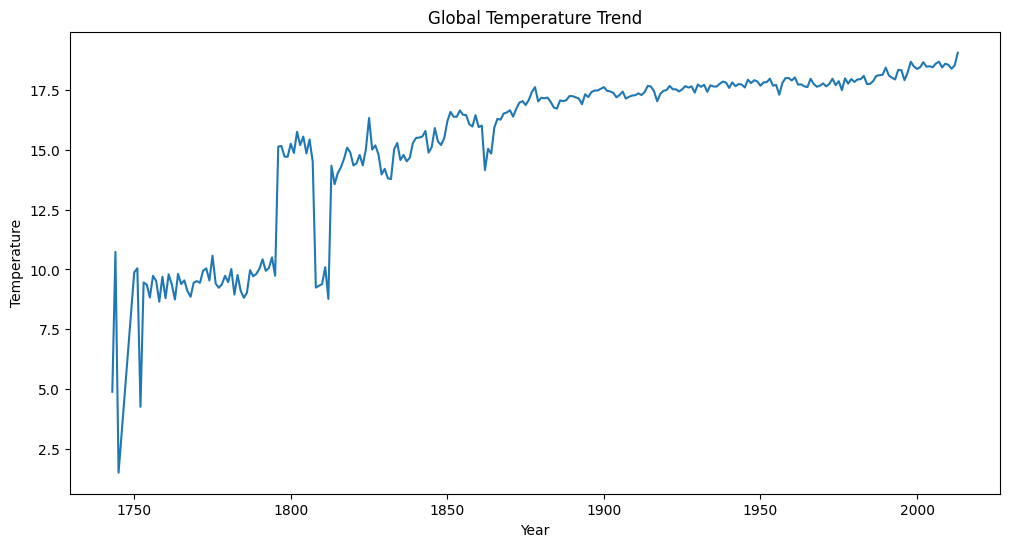

In [10]:
yearly_temp = city_df.groupby('year')['AverageTemperature'].mean()

plt.figure(figsize=(12,6))
plt.plot(yearly_temp.index, yearly_temp.values)

plt.title("Global Temperature Trend")
plt.xlabel("Year")
plt.ylabel("Temperature")
plt.show()

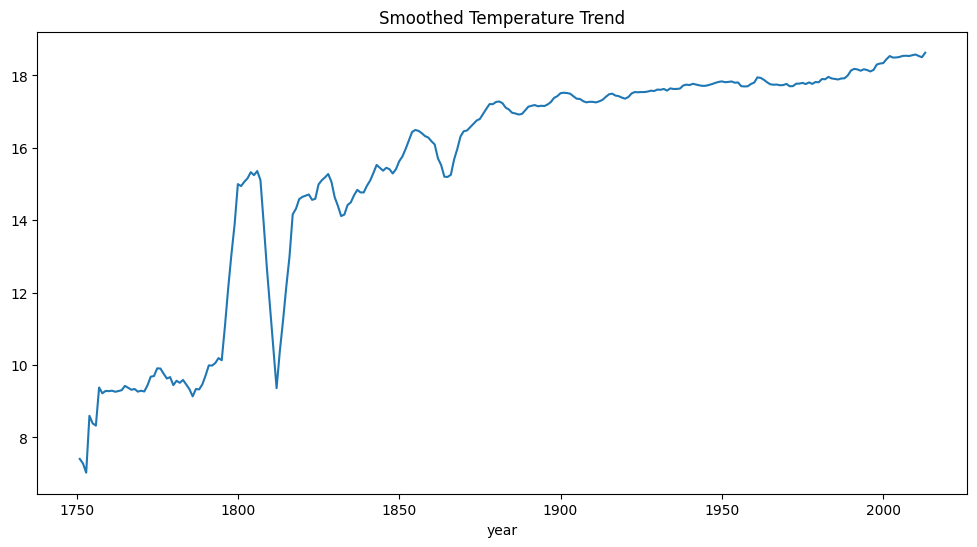

In [11]:
yearly_temp.rolling(5).mean().plot(figsize=(12,6), title="Smoothed Temperature Trend")
plt.show()

In [12]:
city_avg = city_df.groupby('City')['AverageTemperature'].transform('mean')
city_df['anomaly'] = city_df['AverageTemperature'] - city_avg

features = city_df[['AverageTemperature', 'anomaly']]

scaler = StandardScaler()
scaled = scaler.fit_transform(features)

model_iso = IsolationForest(contamination=0.01)
city_df['anomaly_flag'] = model_iso.fit_predict(scaled)

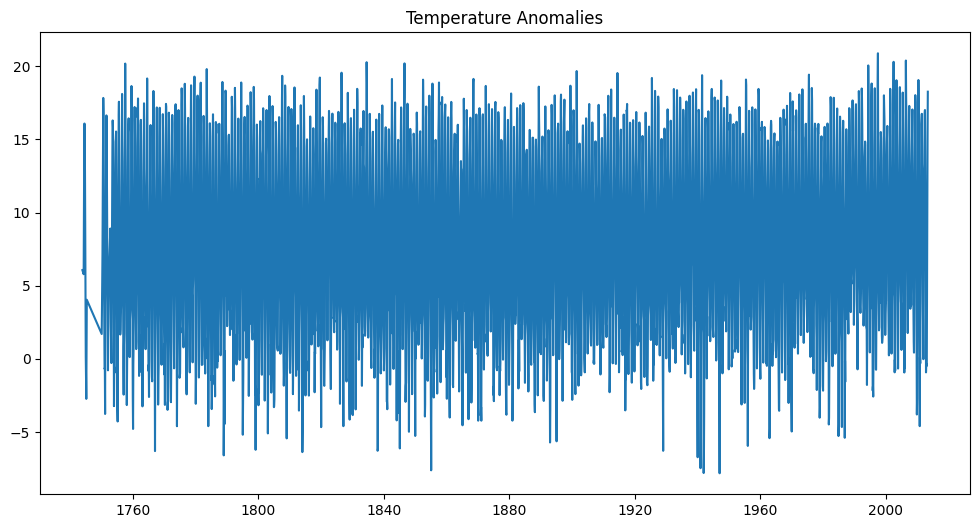

In [13]:
sample_city = city_df[city_df['City'] == city_df['City'].iloc[0]].copy()

# Reduce size to avoid crash
sample_city = sample_city.sample(3000).sort_values('dt')

plt.figure(figsize=(12,6))
plt.plot(sample_city['dt'], sample_city['AverageTemperature'])

anomalies = sample_city[sample_city['anomaly_flag'] == -1]
plt.scatter(anomalies['dt'], anomalies['AverageTemperature'])

plt.title("Temperature Anomalies")
plt.show()

In [14]:
train_df = pd.read_csv('/kaggle/input/datasets/cdminix/us-drought-meteorological-data/train_timeseries/train_timeseries.csv')
val_df = pd.read_csv('/kaggle/input/datasets/cdminix/us-drought-meteorological-data/validation_timeseries/validation_timeseries.csv')
test_df = pd.read_csv('/kaggle/input/datasets/cdminix/us-drought-meteorological-data/test_timeseries/test_timeseries.csv')
soil_df = pd.read_csv('/kaggle/input/datasets/cdminix/us-drought-meteorological-data/soil_data.csv')

In [15]:
df = train_df.merge(soil_df, on='fips', how='left')
df = df.dropna()

In [16]:
print(df.columns)

Index(['fips', 'date', 'PRECTOT', 'PS', 'QV2M', 'T2M', 'T2MDEW', 'T2MWET',
       'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'TS', 'WS10M', 'WS10M_MAX',
       'WS10M_MIN', 'WS10M_RANGE', 'WS50M', 'WS50M_MAX', 'WS50M_MIN',
       'WS50M_RANGE', 'score', 'lat', 'lon', 'elevation', 'slope1', 'slope2',
       'slope3', 'slope4', 'slope5', 'slope6', 'slope7', 'slope8', 'aspectN',
       'aspectE', 'aspectS', 'aspectW', 'aspectUnknown', 'WAT_LAND',
       'NVG_LAND', 'URB_LAND', 'GRS_LAND', 'FOR_LAND', 'CULTRF_LAND',
       'CULTIR_LAND', 'CULT_LAND', 'SQ1', 'SQ2', 'SQ3', 'SQ4', 'SQ5', 'SQ6',
       'SQ7'],
      dtype='object')


In [17]:
df['drought_label'] = (df['score'] > 2).astype(int)

In [18]:
# Drop unnecessary columns
drop_cols = ['drought_label', 'score', 'date']
drop_cols = [col for col in drop_cols if col in df.columns]

X = df.drop(drop_cols, axis=1)
y = df['drought_label']

In [19]:
# Keep only numeric columns (VERY IMPORTANT)
X = X.select_dtypes(include=[np.number])

# Fill missing values
X = X.fillna(0)

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model_rf = RandomForestClassifier(
    n_estimators=50,      # reduce from 200
    max_depth=10,         # limit tree depth
    n_jobs=-1             # use all CPU cores
)
model_rf.fit(X_train, y_train)

y_pred = model_rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92    468377
           1       0.75      0.05      0.09     82983

    accuracy                           0.85    551360
   macro avg       0.80      0.52      0.50    551360
weighted avg       0.84      0.85      0.80    551360



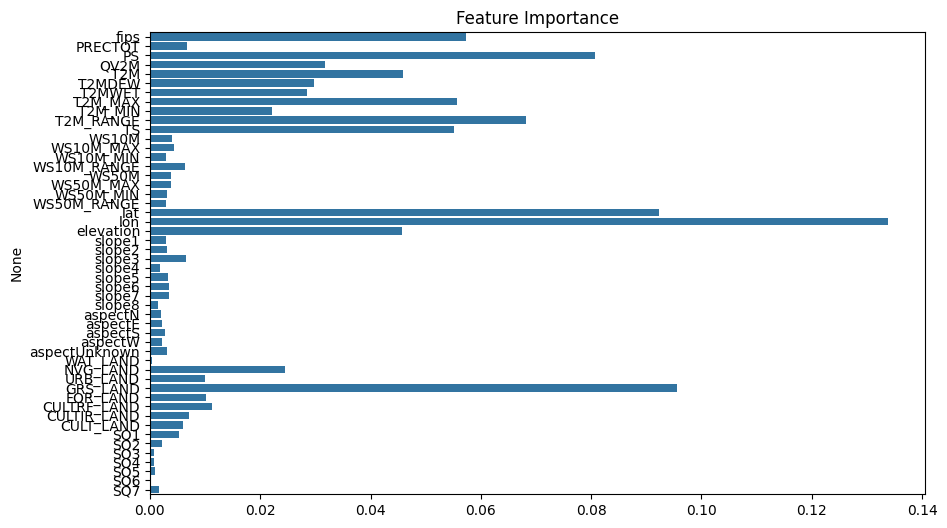

In [22]:
importances = model_rf.feature_importances_

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=X.columns)

plt.title("Feature Importance")
plt.show()

In [18]:
def drought_warning(anomaly, rainfall, soil_moisture):
    if anomaly > 2 and rainfall < 10 and soil_moisture < 0.2:
        return "HIGH RISK"
    elif anomaly > 1:
        return "MEDIUM RISK"
    else:
        return "LOW RISK"

In [19]:
print(drought_warning(2.5, 5, 0.1))

HIGH RISK


In [23]:
import joblib

joblib.dump(model_rf, "drought_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [24]:
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']

In [25]:
model = joblib.load("drought_model.pkl")
feature_cols = joblib.load("feature_columns.pkl")

In [26]:
# Create empty input with all columns
new_data = pd.DataFrame(columns=feature_cols)

# Add one sample row (example values)
new_data.loc[0] = 0

# Now set important features (modify based on your dataset)
if 'rainfall' in new_data.columns:
    new_data['rainfall'] = 5

if 'temperature' in new_data.columns:
    new_data['temperature'] = 35

if 'soil_moisture' in new_data.columns:
    new_data['soil_moisture'] = 0.1

In [27]:
new_data = new_data.fillna(0)

In [28]:
prediction = model.predict(new_data)

print("Raw Prediction:", prediction)

Raw Prediction: [0]


In [29]:
if prediction[0] == 1:
    print("🌵 Drought Likely")
else:
    print("✅ No Drought")

✅ No Drought
